# 균일 HSBM K 변화 - Zhou theta 비랜덤 실험

이 노트북은 `n=5000`, `rho_n=8`을 고정하고 군집 수 `K`만 바꾸는 실험을 실행한다.

균일 HSBM은 `p_in = a_in * rho_n / n ** (m - 1)`, `p_out = b_out * rho_n / n ** (m - 1)`를 사용한다.

Spectral clustering은 Zhou operator `Theta = I - Delta`의 가장 큰 고유값에 대응하는 고유벡터를 사용한다. 이는 `Delta = I - Theta`의 가장 작은 고유값 고유벡터를 쓰는 것과 같은 eigenspace를 사용한다.

`a_in`, `b_out`, `m`, `n`, `rho_n`을 고정한 채 `K`를 바꾸면 within-community 후보 비율도 함께 변한다. 그래서 이 노트북은 경험적 degree와 기대 degree 진단값을 함께 저장한다.


In [1]:
from pathlib import Path
import gc
import json
import math
import sys
import time
import tracemalloc
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

PROJECT_ROOT = Path.cwd()
for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
    if (candidate / "src" / "common.py").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not find project root containing src/common.py")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.common import (
    generate_planted_uniform_hsbm_instance,
    normalize_rows_l2,
    zhou_normalized_laplacian,
)

EXPERIMENT_ID = "EXP-20260427-002"
EXPERIMENT_SLUG = "uniform_hsbm_K_sweep_zhou_theta"
OUTDIR = PROJECT_ROOT / "experiments" / "균일 HSBM 실험" / "results" / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}"
OUTDIR.mkdir(parents=True, exist_ok=True)

EXPERIMENT_ID, EXPERIMENT_SLUG, PROJECT_ROOT, OUTDIR


('EXP-20260427-002',
 'uniform_hsbm_K_sweep_zhou_theta',
 PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research'),
 PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260427-002_uniform_hsbm_K_sweep_zhou_theta'))

## 설정

`K`만 바꾼다. `n=5000`, `rho_n=8.0`은 고정한다.


In [2]:
CONFIG = {
    "n": 5_000,
    "m": 3,
    "a_in": 36.0,
    "b_out": 4.0,
    "rho_n": 8.0,
    "reps": 10,
    "seed": 20260427,
    "sampling": "sparse",
    "max_enumeration": 1_500_000,
    "normalize_embedding_rows": True,
    "eigsh_tol": 1e-6,
    "kmeans_n_init": 20,
}

K_VALUES = [2, 3, 4, 5, 6, 8, 10, 12]

CONFIG, K_VALUES


({'n': 5000,
  'm': 3,
  'a_in': 36.0,
  'b_out': 4.0,
  'rho_n': 8.0,
  'reps': 10,
  'seed': 20260427,
  'sampling': 'sparse',
  'max_enumeration': 1500000,
  'normalize_embedding_rows': True,
  'eigsh_tol': 1e-06,
  'kmeans_n_init': 20},
 [2, 3, 4, 5, 6, 8, 10, 12])

## 보조 함수


In [3]:
def current_rss_mb():
    try:
        import psutil

        return psutil.Process().memory_info().rss / (1024.0 ** 2)
    except Exception:
        return np.nan


def measure_call(fn):
    gc.collect()
    rss_before_mb = current_rss_mb()
    tracemalloc.start()
    cpu_start = time.process_time()
    wall_start = time.perf_counter()
    value = fn()
    wall_clock_sec = time.perf_counter() - wall_start
    cpu_time_sec = time.process_time() - cpu_start
    current_bytes, peak_bytes = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    rss_after_mb = current_rss_mb()
    return value, {
        "cpu_time_sec": float(cpu_time_sec),
        "wall_clock_sec": float(wall_clock_sec),
        "peak_traced_memory_mb": float(peak_bytes / (1024.0 ** 2)),
        "rss_before_mb": float(rss_before_mb) if np.isfinite(rss_before_mb) else np.nan,
        "rss_after_mb": float(rss_after_mb) if np.isfinite(rss_after_mb) else np.nan,
        "rss_delta_mb": float(rss_after_mb - rss_before_mb)
        if np.isfinite(rss_before_mb) and np.isfinite(rss_after_mb)
        else np.nan,
    }


def aligned_misclassification_rate(y_true, y_pred, K):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    conf = np.zeros((K, K), dtype=int)
    for t, p in zip(y_true, y_pred):
        if 0 <= t < K and 0 <= p < K:
            conf[t, p] += 1
    true_ids, pred_ids = linear_sum_assignment(-conf)
    pred_to_true = {int(pred): int(true) for true, pred in zip(true_ids, pred_ids)}
    y_aligned = np.array([pred_to_true.get(int(p), int(p)) for p in y_pred], dtype=int)
    return float(np.mean(y_aligned != y_true)), y_aligned, conf


def hypergraph_vertex_degree_stats(n, hyperedges):
    degrees = np.zeros(int(n), dtype=float)
    for edge in hyperedges:
        for v in edge:
            degrees[int(v)] += 1.0
    return {
        "num_isolated_nodes": int(np.sum(degrees == 0)),
        "isolated_fraction": float(np.mean(degrees == 0)) if n > 0 else 0.0,
        "hypergraph_degree_mean": float(degrees.mean()) if n > 0 else 0.0,
        "hypergraph_degree_max": float(degrees.max()) if n > 0 else 0.0,
    }


def balanced_label_sizes(n, K):
    sizes = np.full(K, n // K, dtype=int)
    sizes[: n % K] += 1
    return sizes


def expected_uniform_hsbm_stats(n, K, m, p_in, p_out):
    sizes = balanced_label_sizes(int(n), int(K))
    total = math.comb(int(n), int(m))
    within = sum(math.comb(int(size), int(m)) for size in sizes if size >= m)
    mixed = total - within
    expected_edges = within * float(p_in) + mixed * float(p_out)
    return {
        "expected_hyperedges_total": float(expected_edges),
        "expected_hyperedges_per_n": float(expected_edges / n),
        "expected_degree_mean": float(m * expected_edges / n),
        "candidate_within_fraction": float(within / total) if total > 0 else np.nan,
    }


def spectral_cluster_from_zhou_theta(theta, K, rng, normalize_rows=True, eigsh_tol=1e-6, kmeans_n_init=20):
    n = int(theta.shape[0])
    theta = ((theta + theta.T) * 0.5).tocsr()
    total_start = time.perf_counter()
    timings = {}

    t0 = time.perf_counter()
    try:
        if n <= K + 1:
            vals, vecs = np.linalg.eigh(theta.toarray())
        else:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=UserWarning)
                vals, vecs = spla.eigsh(
                    theta,
                    k=K,
                    which="LA",
                    tol=float(eigsh_tol),
                    v0=rng.normal(size=n),
                )
    except Exception:
        vals, vecs = np.linalg.eigh(theta.toarray())
    order = np.argsort(vals)[-K:][::-1]
    top_vals = vals[order]
    top_vecs = vecs[:, order]
    U = top_vecs
    timings["eigen_decomposition_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    if normalize_rows:
        U = normalize_rows_l2(U)
    timings["embedding_normalize_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    random_state = int(rng.integers(1, 2**31 - 1))
    labels = KMeans(n_clusters=K, n_init=int(kmeans_n_init), random_state=random_state).fit_predict(U)
    timings["kmeans_wall_sec"] = time.perf_counter() - t0
    timings["spectral_clustering_wall_sec"] = time.perf_counter() - total_start
    return labels, {
        "zhou_theta_nnz": int(theta.nnz),
        **timings,
    }


def run_one_rep(K, rep, config):
    n = int(config["n"])
    K = int(K)
    m = int(config["m"])
    rho_n = float(config["rho_n"])
    seed = int(config["seed"] + 1_000_003 * K + int(rep))
    rng = np.random.default_rng(seed)
    timings = {}

    t0 = time.perf_counter()
    hyperedges, y_true, Theta_true, gen_stats = generate_planted_uniform_hsbm_instance(
        n=n,
        K=K,
        d=m,
        a_d=float(config["a_in"]),
        b_d=float(config["b_out"]),
        rho_n=rho_n,
        rng=rng,
        sampling=config["sampling"],
        max_enumeration=int(config["max_enumeration"]),
        clip=False,
    )
    p_in = float(gen_stats["p_in"])
    p_out = float(gen_stats["p_out"])
    expected_stats = expected_uniform_hsbm_stats(n=n, K=K, m=m, p_in=p_in, p_out=p_out)
    timings["generation_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    L = zhou_normalized_laplacian(n=n, hyperedges=hyperedges)
    theta = (sp.eye(n, format="csr", dtype=float) - L).tocsr()
    theta.eliminate_zeros()
    timings["zhou_theta_build_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred, spectral_stats = spectral_cluster_from_zhou_theta(
        theta=theta,
        K=K,
        rng=rng,
        normalize_rows=bool(config["normalize_embedding_rows"]),
        eigsh_tol=float(config["eigsh_tol"]),
        kmeans_n_init=int(config["kmeans_n_init"]),
    )
    timings["spectral_clustering_wall_sec"] = time.perf_counter() - t0

    t0 = time.perf_counter()
    mis, y_aligned, conf = aligned_misclassification_rate(y_true, y_pred, K)
    ari = adjusted_rand_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    timings["metric_wall_sec"] = time.perf_counter() - t0

    record = {
        "n": n,
        "K": K,
        "rho_n": rho_n,
        "rep": int(rep),
        "seed": seed,
        "m": m,
        "num_hyperedges_total": int(len(hyperedges)),
        "misclassification_rate": mis,
        "ARI": float(ari),
        "NMI": float(nmi),
        **timings,
        **hypergraph_vertex_degree_stats(n, hyperedges),
        **expected_stats,
        **spectral_stats,
    }
    record["algorithm_total_wall_sec"] = float(
        record["generation_wall_sec"]
        + record["zhou_theta_build_wall_sec"]
        + record["eigen_decomposition_wall_sec"]
        + record["embedding_normalize_wall_sec"]
        + record["kmeans_wall_sec"]
    )
    record["p_in"] = float(p_in)
    record["p_out"] = float(p_out)
    record["sampling_mode"] = gen_stats.get("sampling_mode", "")
    return record


def run_one_rep_measured(K, rep, config):
    record, measurement = measure_call(lambda: run_one_rep(K=K, rep=rep, config=config))
    record.update(measurement)
    return record


def run_K_experiment(K, reps=None, config=None):
    if config is None:
        config = CONFIG
    if reps is None:
        reps = int(config["reps"])

    rows = []
    for rep in range(1, reps + 1):
        row = run_one_rep_measured(K=K, rep=rep, config=config)
        rows.append(row)
        print(
            f"K={K:2d} rep={rep:2d}/{reps:<2d} "
            f"edges={row['num_hyperedges_total']:8d} "
            f"degree={row['hypergraph_degree_mean']:.2f} "
            f"expected_degree={row['expected_degree_mean']:.2f} "
            f"isolated={row['isolated_fraction']:.4f} "
            f"mis={row['misclassification_rate']:.4f} "
            f"ARI={row['ARI']:.4f} NMI={row['NMI']:.4f} "
            f"wall={row['wall_clock_sec']:.3f}s "
            f"peak={row['peak_traced_memory_mb']:.1f}MB"
        )

    df = pd.DataFrame(rows)
    display(df)
    return df


def summarize_by_K(df_raw):
    return df_raw.groupby("K", as_index=False).agg(
        reps=("rep", "count"),
        hyperedges_mean=("num_hyperedges_total", "mean"),
        hyperedges_std=("num_hyperedges_total", "std"),
        degree_mean=("hypergraph_degree_mean", "mean"),
        degree_std=("hypergraph_degree_mean", "std"),
        expected_degree_mean=("expected_degree_mean", "mean"),
        candidate_within_fraction_mean=("candidate_within_fraction", "mean"),
        isolated_fraction_mean=("isolated_fraction", "mean"),
        isolated_fraction_std=("isolated_fraction", "std"),
        misclassification_mean=("misclassification_rate", "mean"),
        misclassification_std=("misclassification_rate", "std"),
        ari_mean=("ARI", "mean"),
        ari_std=("ARI", "std"),
        nmi_mean=("NMI", "mean"),
        nmi_std=("NMI", "std"),
        generation_wall_sec_mean=("generation_wall_sec", "mean"),
        zhou_theta_build_wall_sec_mean=("zhou_theta_build_wall_sec", "mean"),
        eigen_decomposition_wall_sec_mean=("eigen_decomposition_wall_sec", "mean"),
        kmeans_wall_sec_mean=("kmeans_wall_sec", "mean"),
        spectral_clustering_wall_sec_mean=("spectral_clustering_wall_sec", "mean"),
        algorithm_total_wall_sec_mean=("algorithm_total_wall_sec", "mean"),
        cpu_time_sec_mean=("cpu_time_sec", "mean"),
        wall_clock_sec_mean=("wall_clock_sec", "mean"),
        peak_traced_memory_mb_mean=("peak_traced_memory_mb", "mean"),
        rss_delta_mb_mean=("rss_delta_mb", "mean"),
    )


## K 변화 실험 실행


In [4]:
frames = []
for K in K_VALUES:
    frames.append(run_K_experiment(K))

df_raw = pd.concat(frames, ignore_index=True)
summary = summarize_by_K(df_raw)

display(summary)


K= 2 rep= 1/10 edges=   79632 degree=47.78 expected_degree=47.95 isolated=0.0000 mis=0.0000 ARI=1.0000 NMI=1.0000 wall=3.121s peak=40.0MB


K= 2 rep= 2/10 edges=   79321 degree=47.59 expected_degree=47.95 isolated=0.0000 mis=0.0000 ARI=1.0000 NMI=1.0000 wall=3.150s peak=39.8MB


K= 2 rep= 3/10 edges=   80518 degree=48.31 expected_degree=47.95 isolated=0.0000 mis=0.0000 ARI=1.0000 NMI=1.0000 wall=3.077s peak=40.4MB


K= 2 rep= 4/10 edges=   80288 degree=48.17 expected_degree=47.95 isolated=0.0000 mis=0.0000 ARI=1.0000 NMI=1.0000 wall=3.156s peak=40.3MB


K= 2 rep= 5/10 edges=   79473 degree=47.68 expected_degree=47.95 isolated=0.0000 mis=0.0000 ARI=1.0000 NMI=1.0000 wall=3.262s peak=39.9MB


...

K=12 rep= 8/10 edges=   28213 degree=16.93 expected_degree=16.87 isolated=0.0000 mis=0.8908 ARI=0.0012 NMI=0.0076 wall=2.102s peak=15.0MB


K=12 rep= 9/10 edges=   28159 degree=16.90 expected_degree=16.87 isolated=0.0000 mis=0.8924 ARI=0.0010 NMI=0.0071 wall=2.180s peak=15.0MB


K=12 rep=10/10 edges=   28098 degree=16.86 expected_degree=16.87 isolated=0.0000 mis=0.8954 ARI=0.0008 NMI=0.0070 wall=2.163s peak=15.0MB


,n,K,rho_n,rep,seed,m,num_hyperedges_total,misclassification_rate,ARI,NMI,...,algorithm_total_wall_sec,p_in,p_out,sampling_mode,cpu_time_sec,wall_clock_sec,peak_traced_memory_mb,rss_before_mb,rss_after_mb,rss_delta_mb
0,5000,12,8.0,1,32260464,3,27913,0.8890,0.001306,0.007738,...,1.932303,0.000012,0.000001,sparse,8.798932,2.030241,14.874009,283.937500,285.171875,1.234375
1,5000,12,8.0,2,32260465,3,28187,0.8912,0.000807,0.006540,...,1.995975,0.000012,0.000001,sparse,8.603909,2.102895,15.014983,285.171875,286.390625,1.218750
2,5000,12,8.0,3,32260466,3,27834,0.8964,0.000170,0.005256,...,2.136443,0.000012,0.000001,sparse,9.531701,2.233468,14.836831,286.390625,286.500000,0.109375
3,5000,12,8.0,4,32260467,3,28091,0.8940,0.000436,0.005860,...,1.999379,0.000012,0.000001,sparse,8.681838,2.095802,14.964319,286.500000,286.875000,0.375000
4,5000,12,8.0,5,32260468,3,27909,0.8918,0.000793,0.006630,...,1.985498,0.000012,0.000001,sparse,8.703639,2.081673,14.879265,286.875000,287.703125,0.828125
5,5000,12,8.0,6,32260469,3,28011,0.8942,0.000503,0.006006,...,1.987638,0.000012,0.000001,sparse,8.811826,2.091432,14.923715,287.703125,287.718750,0.015625
6,5000,12,8.0,7,32260470,3,28154,0.8906,0.001665,0.008706,...,2.059341,0.000012,0.000001,sparse,8.900120,2.167687,15.005067,287.718750,287.718750,0.000000
7,5000,12,8.0,8,32260471,3,28213,0.8908,0.001248,0.007625,...,2.003606,0.000012,0.000001,sparse,8.822740,2.102178,15.026955,287.718750,287.734375,0.015625
8,5000,12,8.0,9,32260472,3,28159,0.8924,0.000971,0.007099,...,2.068761,0.000012,0.000001,sparse,9.225007,2.180025,15.001568,287.734375,288.187500,0.453125
9,5000,12,8.0,10,32260473,3,28098,0.8954,0.000845,0.007018,...,2.059752,0.000012,0.000001,sparse,9.410442,2.162863,14.967686,288.187500,289.046875,0.859375


,K,reps,hyperedges_mean,hyperedges_std,degree_mean,degree_std,expected_degree_mean,candidate_within_fraction_mean,isolated_fraction_mean,isolated_fraction_std,...,generation_wall_sec_mean,zhou_theta_build_wall_sec_mean,eigen_decomposition_wall_sec_mean,kmeans_wall_sec_mean,spectral_clustering_wall_sec_mean,algorithm_total_wall_sec_mean,cpu_time_sec_mean,wall_clock_sec_mean,peak_traced_memory_mb_mean,rss_delta_mb_mean
0,2,10,79990.3,430.827640,47.99418,0.258497,47.952012,0.249850,0.0,0.0,...,2.595090,0.182018,0.008021,0.069035,0.077134,2.854237,5.179929,3.186507,40.130667,9.932813
1,3,10,50312.3,180.027189,30.18738,0.108016,30.187037,0.110978,0.0,0.0,...,1.727851,0.113035,0.008596,0.071959,0.080636,1.921518,4.265260,2.135282,25.591685,1.571875
2,4,10,39967.1,191.958010,23.98026,0.115175,23.971212,0.062388,0.0,0.0,...,1.423391,0.084265,0.009265,0.098027,0.107401,1.615053,3.902713,1.778690,20.531720,-0.396875
3,5,10,35035.0,160.707464,21.02100,0.096424,21.095052,0.039904,0.0,0.0,...,1.255643,0.074704,0.014175,0.168804,0.183102,1.513445,4.042590,1.665417,18.133568,-6.617188
4,6,10,32669.1,184.897840,19.60146,0.110939,19.533170,0.027694,0.0,0.0,...,1.157699,0.071689,0.033433,0.446236,0.479764,1.709148,6.096630,1.826687,17.003609,1.470312
5,8,10,29932.8,130.186874,17.95968,0.078112,17.980812,0.015559,0.0,0.0,...,1.077101,0.065440,0.051026,0.681334,0.732505,1.875042,7.555230,1.985653,15.726104,0.246875
6,10,10,28764.6,160.496590,17.25876,0.096298,17.262732,0.009946,0.0,0.0,...,1.063821,0.067354,0.067288,0.774826,0.842280,1.973451,7.310948,2.103295,15.223063,-12.710938
7,12,10,28056.9,132.652805,16.83414,0.079592,16.872904,0.006899,0.0,0.0,...,1.030029,0.062700,0.071061,0.858865,0.930146,2.022870,8.949015,2.124826,14.949440,0.510938


## 결과 저장


In [5]:
raw_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_raw.csv"
summary_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_summary.csv"
config_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_config.json"

df_raw.to_csv(raw_path, index=False)
summary.to_csv(summary_path, index=False)
with config_path.open("w", encoding="utf-8") as f:
    json.dump({"CONFIG": CONFIG, "K_VALUES": K_VALUES}, f, indent=2)

raw_path, summary_path, config_path


(PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260427-002_uniform_hsbm_K_sweep_zhou_theta/EXP-20260427-002_uniform_hsbm_K_sweep_zhou_theta_raw.csv'),
 PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260427-002_uniform_hsbm_K_sweep_zhou_theta/EXP-20260427-002_uniform_hsbm_K_sweep_zhou_theta_summary.csv'),
 PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260427-002_uniform_hsbm_K_sweep_zhou_theta/EXP-20260427-002_uniform_hsbm_K_sweep_zhou_theta_config.json'))

## 그림


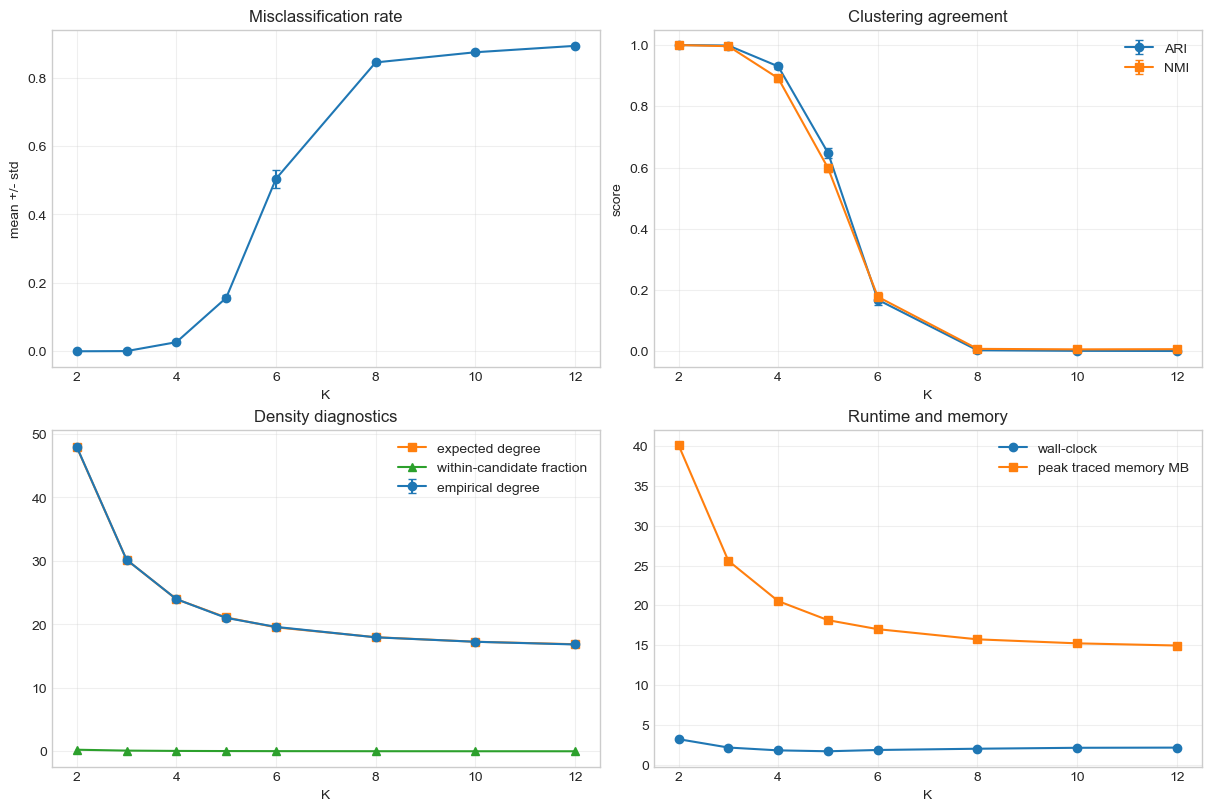

PosixPath('/Users/eomjeonghyeon/Documents/github_project/python-rand-nla-research/experiments/균일 HSBM 실험/results/EXP-20260427-002_uniform_hsbm_K_sweep_zhou_theta/EXP-20260427-002_uniform_hsbm_K_sweep_zhou_theta_summary.png')

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
x = summary["K"].to_numpy()

axes[0, 0].errorbar(
    x,
    summary["misclassification_mean"],
    yerr=summary["misclassification_std"].fillna(0.0),
    marker="o",
    capsize=3,
)
axes[0, 0].set_title("Misclassification rate")
axes[0, 0].set_xlabel("K")
axes[0, 0].set_ylabel("mean +/- std")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].errorbar(x, summary["ari_mean"], yerr=summary["ari_std"].fillna(0.0), marker="o", capsize=3, label="ARI")
axes[0, 1].errorbar(x, summary["nmi_mean"], yerr=summary["nmi_std"].fillna(0.0), marker="s", capsize=3, label="NMI")
axes[0, 1].set_title("Clustering agreement")
axes[0, 1].set_xlabel("K")
axes[0, 1].set_ylabel("score")
axes[0, 1].set_ylim(-0.05, 1.05)
axes[0, 1].grid(alpha=0.3)
axes[0, 1].legend()

axes[1, 0].errorbar(x, summary["degree_mean"], yerr=summary["degree_std"].fillna(0.0), marker="o", capsize=3, label="empirical degree")
axes[1, 0].plot(x, summary["expected_degree_mean"], marker="s", label="expected degree")
axes[1, 0].plot(x, summary["candidate_within_fraction_mean"], marker="^", label="within-candidate fraction")
axes[1, 0].set_title("Density diagnostics")
axes[1, 0].set_xlabel("K")
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()

axes[1, 1].errorbar(x, summary["wall_clock_sec_mean"], marker="o", capsize=3, label="wall-clock")
axes[1, 1].errorbar(x, summary["peak_traced_memory_mb_mean"], marker="s", capsize=3, label="peak traced memory MB")
axes[1, 1].set_title("Runtime and memory")
axes[1, 1].set_xlabel("K")
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend()

fig_path = OUTDIR / f"{EXPERIMENT_ID}_{EXPERIMENT_SLUG}_summary.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()

fig_path
